<a href="https://colab.research.google.com/github/Korayem22/My_Learning_Journey/blob/main/9-DeepLearning/SGD_using_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
!pip install pandas
!pip install torch


In [173]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [183]:
a = torch.tensor(1.0,requires_grad=True)
b = torch.tensor(1.0,requires_grad=True)
#c = torch.tensor(1.0,requires_grad=True)

In [184]:
df = pd.read_csv('data.csv')

In [185]:
X=torch.tensor(df['x'])
Y=torch.tensor(df['y'])
model = lambda x: a * torch.exp(b*x)

In [186]:
weights =[a,b]

In [187]:
loss_fun = lambda y_pred,y:((y_pred-y)**2).mean()

In [188]:
optimizer = torch.optim.SGD(weights,lr=0.0005)

In [189]:
def train_one_eopch(model,optimizer,X,Y,bs):
    indecies = np.random.permutation(len(X))
    losses = []
    a_vals = []
    b_vals = []
    c_vals = []
    for i in range(0,len(X),bs):
        optimizer.zero_grad()
        batch_indecies = indecies[i:i+bs]
        batch_X = X[batch_indecies]
        batch_Y = Y[batch_indecies]
        y_pred = model(batch_X)
        loss = loss_fun(y_pred,batch_Y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        a_vals.append(a.item())
        b_vals.append(b.item())
        c_vals.append(c.item())
        #print(f'loss:{loss.item()} a:{a.item()} b:{b.item()} c:{c.item()}')
    return losses,a_vals,b_vals,c_vals

In [190]:
losses = []
a_vals = []
b_vals = []
for i in range(1000):
    loss,a_val,b_val,c_val = train_one_eopch(model,optimizer,X,Y,bs=100)
    losses.extend(loss)
    a_vals.extend(a_val)
    b_vals.extend(b_val)
    if i%100==0:
        print(f'loss:{losses[-1]} a:{a_vals[-1]} b:{b_vals[-1]}')
print(len(losses))

loss:1276.336975977627 a:1.0385440587997437 b:1.02975594997406
loss:19.99490962526626 a:3.216235876083374 b:3.847686767578125
loss:17.430553153821446 a:3.553893804550171 b:3.7346608638763428
loss:15.935660689065468 a:3.813960075378418 b:3.6544649600982666
loss:15.013136476985938 a:4.019385814666748 b:3.5947556495666504
loss:14.421483646705804 a:4.184515476226807 b:3.548846483230591
loss:14.03146450730975 a:4.318946838378906 b:3.5127367973327637
loss:13.769075207440366 a:4.429429531097412 b:3.483856439590454
loss:13.5897795260794 a:4.52089786529541 b:3.460463047027588
loss:13.465770747266829 a:4.597058296203613 b:3.4413273334503174
1000


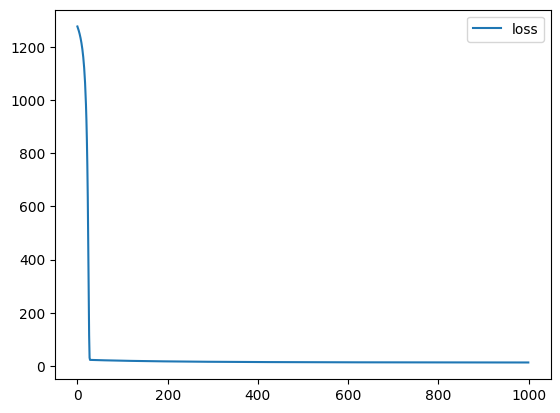

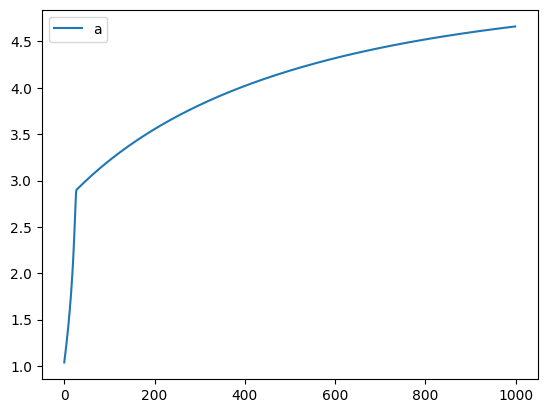

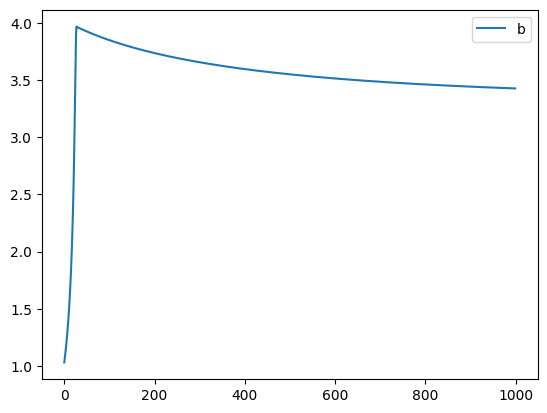

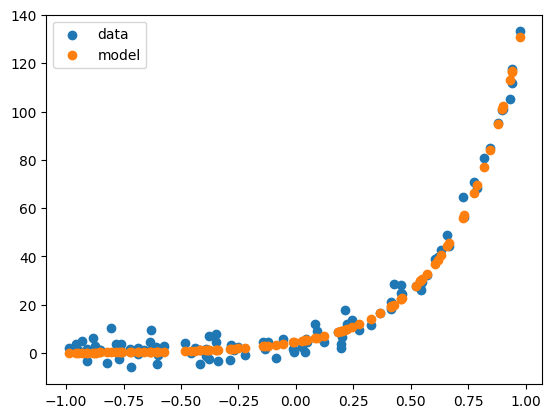

In [191]:
plt.plot(np.arange(len(losses)),losses,label='loss')
plt.legend()
plt.show()
plt.plot(np.arange(len(a_vals)),a_vals,label='a')
plt.legend()
plt.show()
plt.plot(np.arange(len(b_vals)),b_vals,label='b')
plt.legend()
plt.show()
plt.scatter(df['x'],df['y'],label='data')
with torch.no_grad():
    y_pred = model(X)
    plt.scatter(X,y_pred,label='model')
    plt.legend()
    plt.show()